In [1]:
# !pip install -q kaggle

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# !pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print(path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia


In [4]:
import os

print(os.listdir("/kaggle/input/chest-xray-pneumonia"))

['chest_xray']


In [5]:
train_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"

In [6]:
!pip install tensorflow

In [7]:
import tensorflow as tf

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(124,124),
    batch_size=32
)
test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(124,124),
    batch_size=32
)

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


length of images: 32
length of labels: 32
shape of images: (32, 124, 124, 3)
shape of labels: (32,)


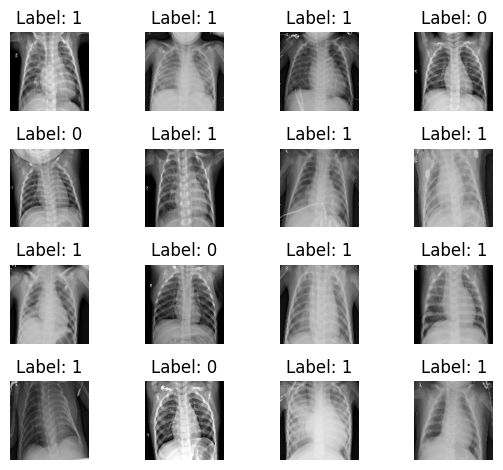

In [8]:
import matplotlib.pyplot as plt

for images, labels in train_data.take(1):
    print(f'length of images: {len(images)}')
    print(f'length of labels: {len(labels)}')
    print(f'shape of images: {images.shape}')
    print(f'shape of labels: {labels.shape}')

    for i in range(16):
        ax = plt.subplot(4,4,i+1)
        # Show image
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Label: {labels[i].numpy()}")
        plt.axis("off")
        plt.tight_layout()
plt.show()

In [9]:

validation_data = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(124, 124),
    batch_size=32
)

Found 16 files belonging to 2 classes.



# =========================
# DATA AUGMENTATION
# =========================

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomBrightness(0.1),
], name="data_augmentation")

# =========================
# LOAD PRETRAINED MODEL
# =========================

In [11]:


base_model = tf.keras.applications.MobileNetV2(
    input_shape=(124, 124, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# =========================
# BUILD MODEL
# =========================
inputs = tf.keras.Input(shape=(124, 124, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(2, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

/tmp/ipykernel_822/852276676.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# =========================
# COMPILE MODEL
# =========================

In [12]:

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

# =========================
# CALLBACKS
# =========================
early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=2,

    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(

    'best_mobilenetv2.keras',

    monitor='val_loss',

    save_best_only=True
)

# =========================
# TRAIN MODEL
# =========================
history = model.fit(

    train_data,

    validation_data=validation_data,

    epochs=5,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 62s 303ms/step - accuracy: 0.8635 - loss: 0.3400 - val_accuracy: 0.7500 - val_loss: 0.8785 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 209ms/step - accuracy: 0.9172 - loss: 0.2089 - val_accuracy: 0.7500 - val_loss: 0.9114 - learning_rate: 1.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9225 - loss: 0.1978
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 213ms/step - accuracy: 0.9245 - loss: 0.1873 - val_accuracy: 0.8125 - val_loss: 0.9045 - learning_rate: 1.0000e-04
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 207ms/step - accuracy: 0.9325 - loss: 0.1723 - val_accuracy: 0.8125 - val_loss: 0.9488 - learning_rate: 5.0000e-05
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 223ms/step - accuracy: 0.9367 - loss: 0.1568 - val_accuracy: 0.8125 - val_loss: 0.8304 - learning_rate: 5.0000e-05
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 214ms/st

[0.8634969592094421, 0.9171779155731201, 0.9244632124900818, 0.9325153231620789, 0.9367331266403198, 0.9409509301185608, 0.9371165633201599, 0.9432515501976013, 0.9428681135177612, 0.946319043636322, 0.9490030407905579]


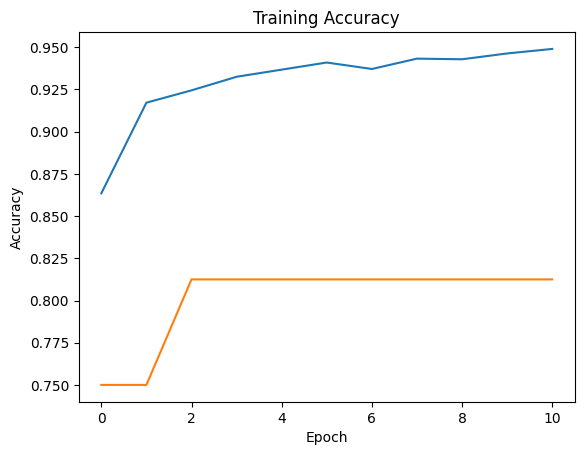

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
print(history.history['accuracy'])
plt.show()

In [18]:
# from tensorflow.keras.models import load_model
# #
# model = load_model("best_mobilenetv2.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


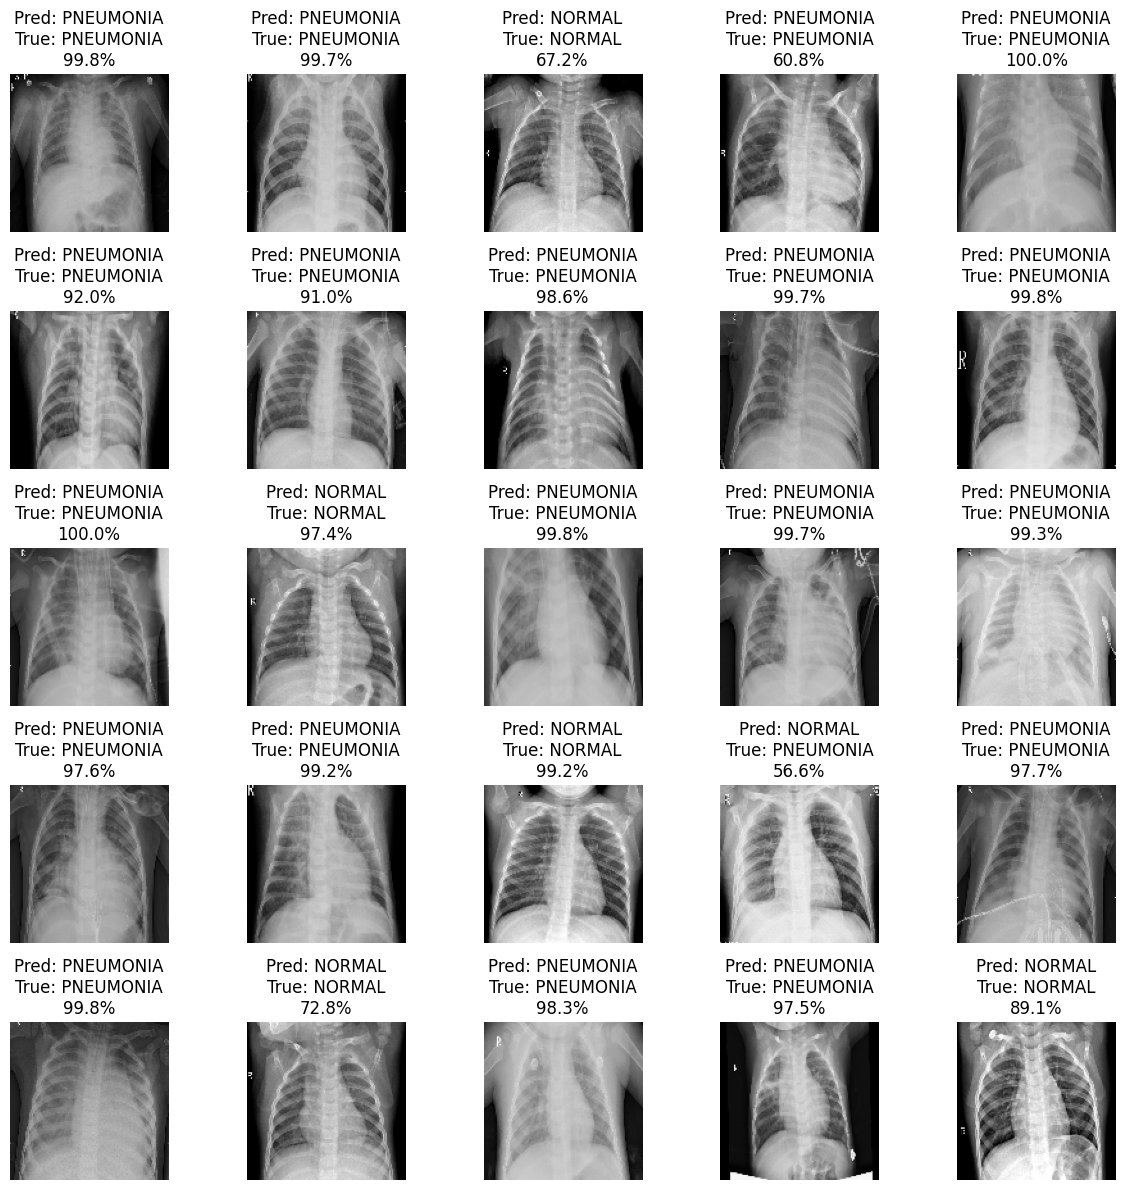

In [19]:
import numpy as np

plt.figure(figsize=(12,12))

class_names = train_data.class_names

for images, labels in train_data.take(1):

    predictions = model.predict(images)
    for i in range(25):

        ax = plt.subplot(5,5,i+1)

        # Show image
        plt.imshow(images[i].numpy().astype("uint8"))

        # Prediction
        predicted_class = np.argmax(predictions[i])

        predicted_label = class_names[predicted_class]

        confidence = np.max(predictions[i]) * 100

        true_label = class_names[labels[i]]

        # Title
        plt.title(
            f"Pred: {predicted_label}\n"
            f"True: {true_label}\n"
            f"{confidence:.1f}%"
        )

        plt.axis("off")
plt.tight_layout()
plt.show()

In [20]:
os.makedirs('/content/drive/MyDrive/models', exist_ok=True)

In [21]:
model.save('/content/drive/MyDrive/models/pneumonia_cnn.keras')
print("Model saved successfully!")

Model saved successfully!


In [22]:
model = tf.keras.models.load_model('/content/drive/MyDrive/models/pneumonia_cnn.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


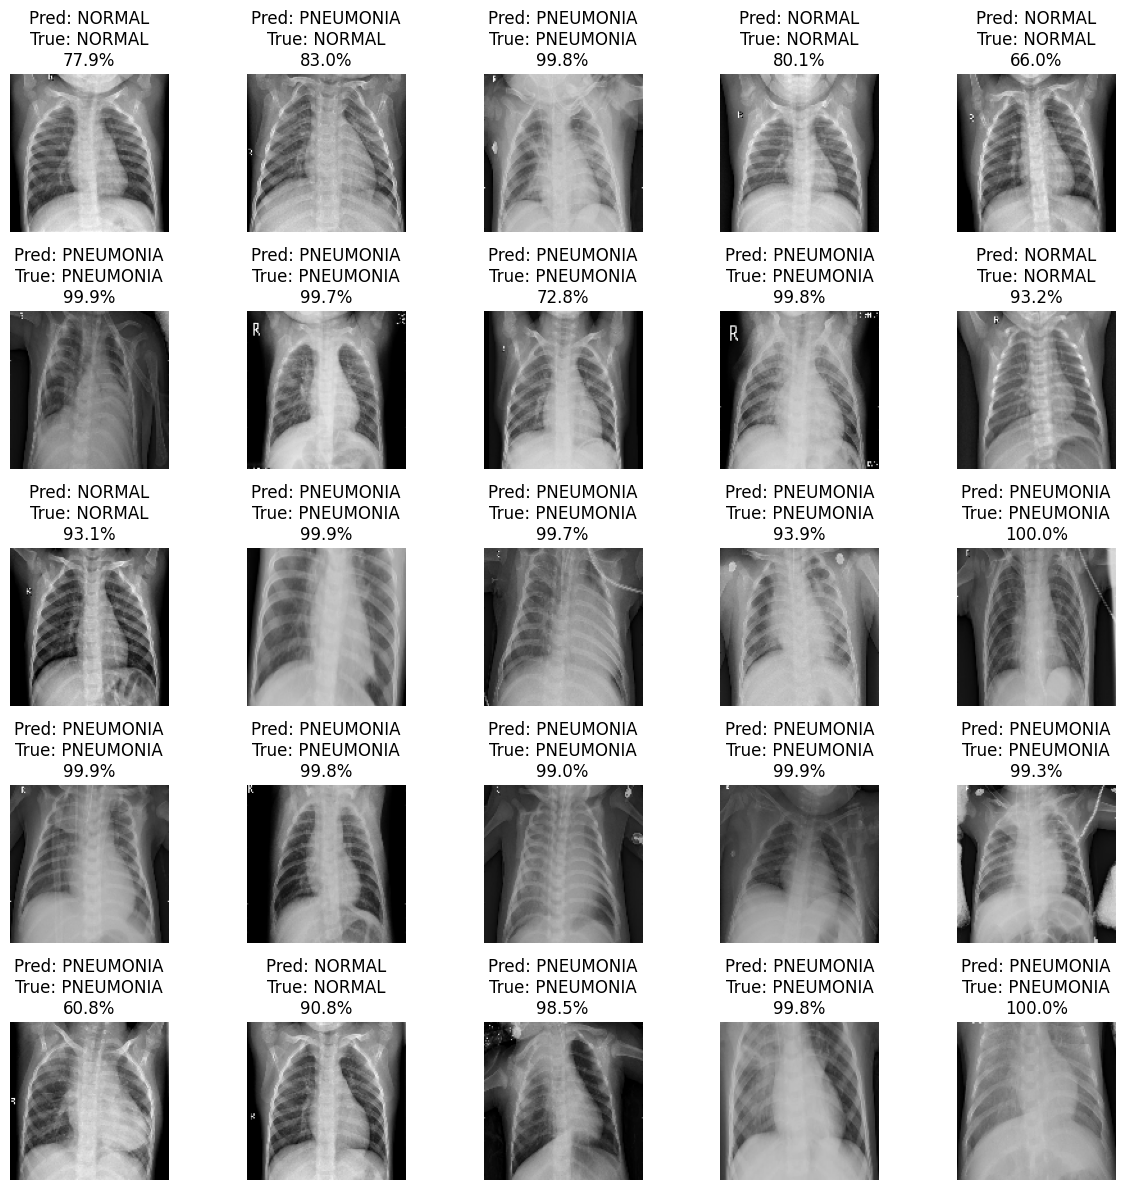

In [23]:
import numpy as np

plt.figure(figsize=(12,12))

class_names = train_data.class_names

for images, labels in train_data.take(1):

    predictions = model.predict(images)
    for i in range(25):

        ax = plt.subplot(5,5,i+1)

        # Show image
        plt.imshow(images[i].numpy().astype("uint8"))

        # Prediction
        predicted_class = np.argmax(predictions[i])

        predicted_label = class_names[predicted_class]

        confidence = np.max(predictions[i]) * 100

        true_label = class_names[labels[i]]

        # Title
        plt.title(
            f"Pred: {predicted_label}\n"
            f"True: {true_label}\n"
            f"{confidence:.1f}%"
        )

        plt.axis("off")
plt.tight_layout()
plt.show()